In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont, ImageFilter

np.random.seed(42)

In [2]:
def make_digit_image(digit, img_size=28, shift_range=3, blur=False, noise_level=0.0):
    img = Image.new("L", (img_size, img_size), color=0)
    draw = ImageDraw.Draw(img)
    font = ImageFont.load_default()

    text = str(digit)

    bbox = draw.textbbox((0, 0), text, font=font)
    text_w = bbox[2] - bbox[0]
    text_h = bbox[3] - bbox[1]

    dx = np.random.randint(-shift_range, shift_range + 1)
    dy = np.random.randint(-shift_range, shift_range + 1)

    x = (img_size - text_w) // 2 + dx
    y = (img_size - text_h) // 2 + dy

    draw.text((x, y), text, fill=255, font=font)

    if blur:
        img = img.filter(ImageFilter.GaussianBlur(radius=np.random.uniform(0.0, 0.8)))

    arr = np.array(img).astype(np.float32) / 255.0

    if noise_level > 0:
        noise = np.random.normal(0, noise_level, arr.shape)
        arr = np.clip(arr + noise, 0, 1)

    return arr

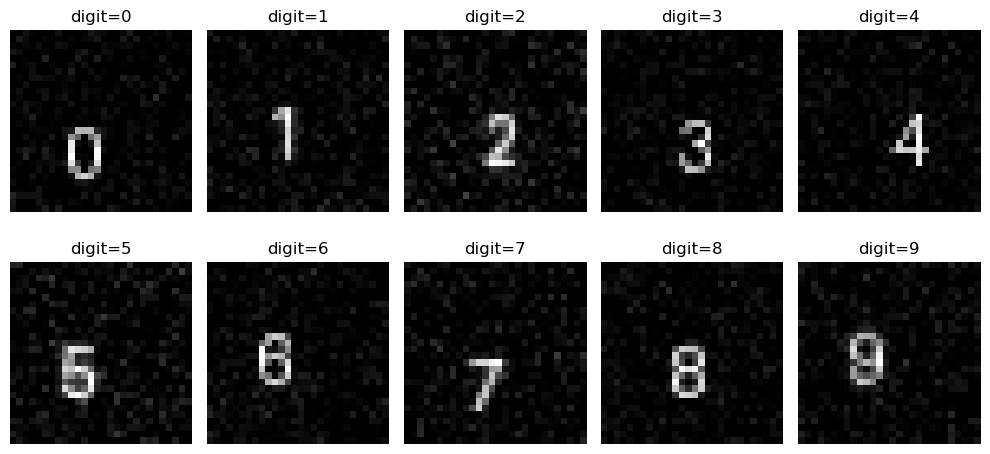

In [4]:
plt.figure(figsize=(10, 5))
for d in range(10):
    img = make_digit_image(d, blur=True, noise_level=0.05)
    plt.subplot(2, 5, d + 1)
    plt.imshow(img, cmap="gray")
    plt.title(f"digit={d}")
    plt.axis("off")
plt.tight_layout()
plt.show()

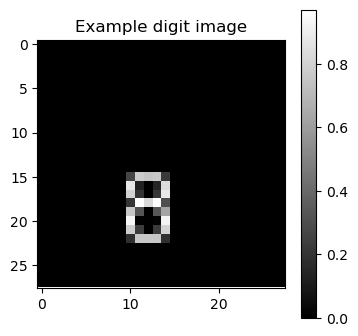

shape = (28, 28)


In [6]:
img_example = make_digit_image(8, blur=False, noise_level=0.0)

plt.figure(figsize=(4, 4))
plt.imshow(img_example, cmap="gray")
plt.title("Example digit image")
plt.colorbar()
plt.show()

print("shape =", img_example.shape)
# print(img_example)

In [7]:
def make_dataset(samples_per_digit=100, img_size=28):
    X = []
    y = []

    for digit in range(10):
        for _ in range(samples_per_digit):
            img = make_digit_image(
                digit,
                img_size=img_size,
                shift_range=3,
                blur=np.random.rand() < 0.5,
                noise_level=np.random.uniform(0.0, 0.08)
            )
            X.append(img)
            y.append(digit)

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.int64)
    return X, y

In [8]:
X, y = make_dataset(samples_per_digit=80)

print("X.shape =", X.shape)
print("y.shape =", y.shape)
print("类别范围 =", np.unique(y))

X.shape = (800, 28, 28)
y.shape = (800,)
类别范围 = [0 1 2 3 4 5 6 7 8 9]


In [10]:
def train_test_split(X, y, test_ratio=0.2):
    idx = np.arange(len(X))
    np.random.shuffle(idx)

    split = int(len(X) * (1 - test_ratio))
    train_idx = idx[:split]
    test_idx = idx[split:]

    return X[train_idx], y[train_idx], X[test_idx], y[test_idx]

X_train, y_train, X_test, y_test = train_test_split(X, y, test_ratio=0.2)

print("X_train.shape =", X_train.shape)
print("X_test.shape  =", X_test.shape)

X_train.shape = (640, 28, 28)
X_test.shape  = (160, 28, 28)


In [11]:
def one_hot(y, num_classes=10):
    out = np.zeros((len(y), num_classes), dtype=np.float32)
    out[np.arange(len(y)), y] = 1.0
    return out

Y_train = one_hot(y_train, 10)
Y_test = one_hot(y_test, 10)

In [12]:
def conv_forward_single(x, K, b):
    """
    x: (H, W)
    K: (F, Kh, Kw)
    b: (F,)
    out: (F, H_out, W_out)
    """
    H, W = x.shape
    F, Kh, Kw = K.shape

    H_out = H - Kh + 1
    W_out = W - Kw + 1

    out = np.zeros((F, H_out, W_out), dtype=np.float32)

    for f in range(F):
        for i in range(H_out):
            for j in range(W_out):
                region = x[i:i+Kh, j:j+Kw]
                out[f, i, j] = np.sum(region * K[f]) + b[f]

    return out

In [13]:
def relu(x):
    return np.maximum(0, x)

def relu_backward(grad_out, x):
    grad = grad_out.copy()
    grad[x <= 0] = 0
    return grad

In [14]:
def avgpool_forward(x, pool=2, stride=2):
    """
    x: (F, H, W)
    """
    F, H, W = x.shape
    H_out = (H - pool) // stride + 1
    W_out = (W - pool) // stride + 1

    out = np.zeros((F, H_out, W_out), dtype=np.float32)

    for f in range(F):
        for i in range(H_out):
            for j in range(W_out):
                region = x[f, i*stride:i*stride+pool, j*stride:j*stride+pool]
                out[f, i, j] = np.mean(region)

    return out


def avgpool_backward(grad_out, x_shape, pool=2, stride=2):
    F, H, W = x_shape
    grad_x = np.zeros(x_shape, dtype=np.float32)

    H_out, W_out = grad_out.shape[1], grad_out.shape[2]

    for f in range(F):
        for i in range(H_out):
            for j in range(W_out):
                grad = grad_out[f, i, j] / (pool * pool)
                grad_x[f, i*stride:i*stride+pool, j*stride:j*stride+pool] += grad

    return grad_x

In [15]:
def flatten(x):
    return x.reshape(-1)

def fc_forward(x, W, b):
    return W @ x + b

def softmax(z):
    z = z - np.max(z)
    exp_z = np.exp(z)
    return exp_z / np.sum(exp_z)

def cross_entropy_loss(prob, y_true_onehot):
    return -np.sum(y_true_onehot * np.log(prob + 1e-12))

In [16]:
F = 4
Kh = Kw = 3

K = np.random.randn(F, Kh, Kw).astype(np.float32) * 0.1
b_conv = np.zeros(F, dtype=np.float32)

flat_dim = F * 13 * 13   # 4×13×13 = 676
W_fc = np.random.randn(10, flat_dim).astype(np.float32) * 0.1
b_fc = np.zeros(10, dtype=np.float32)

print("K.shape =", K.shape)
print("W_fc.shape =", W_fc.shape)

K.shape = (4, 3, 3)
W_fc.shape = (10, 676)


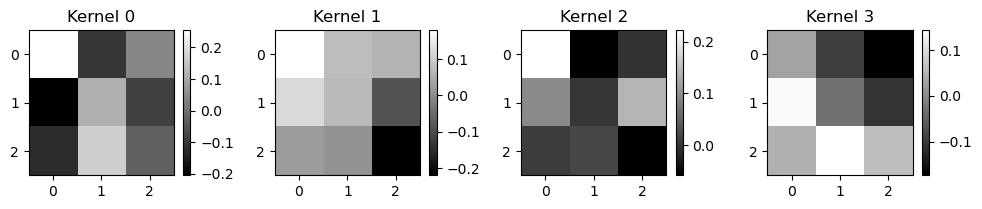

In [17]:
plt.figure(figsize=(10, 2))
for f in range(F):
    plt.subplot(1, F, f + 1)
    plt.imshow(K[f], cmap="gray")
    plt.title(f"Kernel {f}")
    plt.colorbar()
plt.tight_layout()
plt.show()

In [18]:
def single_channel_cnn_forward(x, K, b_conv, W_fc, b_fc):
    z1 = conv_forward_single(x, K, b_conv)        # (4, 26, 26)
    a1 = relu(z1)                                 # (4, 26, 26)
    p1 = avgpool_forward(a1, pool=2, stride=2)    # (4, 13, 13)
    f1 = flatten(p1)                              # (676,)
    z2 = fc_forward(f1, W_fc, b_fc)               # (10,)
    prob = softmax(z2)                            # (10,)

    cache = {
        "x": x,
        "z1": z1,
        "a1": a1,
        "p1": p1,
        "f1": f1,
        "z2": z2,
        "prob": prob
    }

    return prob, cache

In [19]:
sample = X_train[0]
prob, cache = single_channel_cnn_forward(sample, K, b_conv, W_fc, b_fc)

print("Input shape =", sample.shape)
print("Conv output shape =", cache["z1"].shape)
print("Pool output shape =", cache["p1"].shape)
print("Flatten shape =", cache["f1"].shape)
print("Prob shape =", cache["prob"].shape)
print("Predicted class =", np.argmax(cache["prob"]))

Input shape = (28, 28)
Conv output shape = (4, 26, 26)
Pool output shape = (4, 13, 13)
Flatten shape = (676,)
Prob shape = (10,)
Predicted class = 6


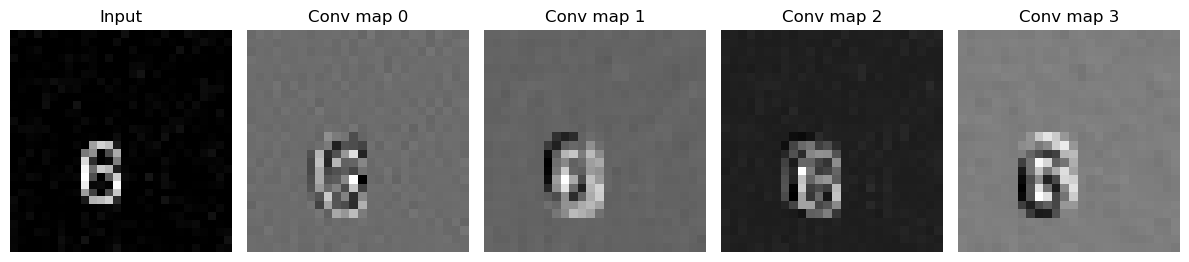

In [20]:
plt.figure(figsize=(12, 3))

plt.subplot(1, 5, 1)
plt.imshow(sample, cmap="gray")
plt.title("Input")
plt.axis("off")

for f in range(F):
    plt.subplot(1, 5, f + 2)
    plt.imshow(cache["z1"][f], cmap="gray")
    plt.title(f"Conv map {f}")
    plt.axis("off")

plt.tight_layout()
plt.show()

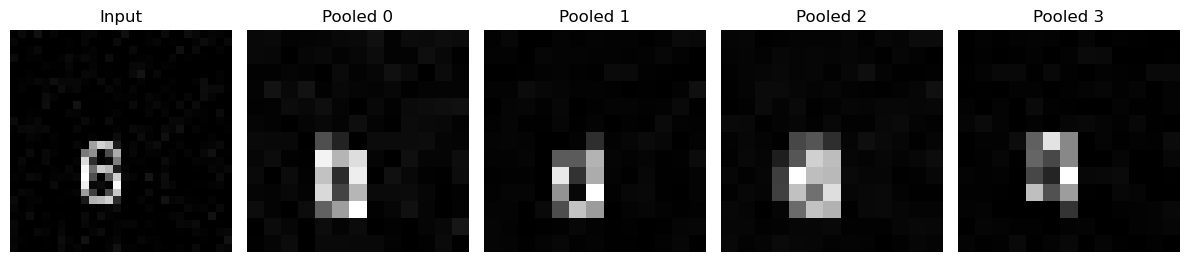

In [21]:
plt.figure(figsize=(12, 3))

plt.subplot(1, 5, 1)
plt.imshow(sample, cmap="gray")
plt.title("Input")
plt.axis("off")

for f in range(F):
    plt.subplot(1, 5, f + 2)
    plt.imshow(cache["p1"][f], cmap="gray")
    plt.title(f"Pooled {f}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [22]:
def backward_single_channel_cnn(y_true, cache, K, W_fc):
    x = cache["x"]
    z1 = cache["z1"]
    a1 = cache["a1"]
    p1 = cache["p1"]
    f1 = cache["f1"]
    prob = cache["prob"]

    F, Kh, Kw = K.shape

    dz2 = prob - y_true
    dW_fc = np.outer(dz2, f1)
    db_fc = dz2.copy()

    df1 = W_fc.T @ dz2
    dp1 = df1.reshape(p1.shape)

    da1 = avgpool_backward(dp1, a1.shape, pool=2, stride=2)
    dz1 = relu_backward(da1, z1)

    dK = np.zeros_like(K)
    db_conv = np.zeros(F, dtype=np.float32)
    dx = np.zeros_like(x)

    H_out, W_out = dz1.shape[1], dz1.shape[2]

    for f in range(F):
        db_conv[f] = np.sum(dz1[f])

        for i in range(H_out):
            for j in range(W_out):
                region = x[i:i+Kh, j:j+Kw]
                dK[f] += dz1[f, i, j] * region
                dx[i:i+Kh, j:j+Kw] += dz1[f, i, j] * K[f]

    grads = {
        "dK": dK,
        "db_conv": db_conv,
        "dW_fc": dW_fc,
        "db_fc": db_fc
    }
    return grads

In [23]:
def predict_one(x, K, b_conv, W_fc, b_fc):
    prob, _ = single_channel_cnn_forward(x, K, b_conv, W_fc, b_fc)
    return np.argmax(prob), prob

In [24]:
def train_cnn(X_train, Y_train, X_test, y_test,
              K, b_conv, W_fc, b_fc,
              epochs=5, lr=0.01):

    train_losses = []
    test_accs = []

    for epoch in range(epochs):
        total_loss = 0.0

        idx = np.arange(len(X_train))
        np.random.shuffle(idx)

        for n in idx:
            x = X_train[n]
            y_true = Y_train[n]

            prob, cache = single_channel_cnn_forward(x, K, b_conv, W_fc, b_fc)
            loss = cross_entropy_loss(prob, y_true)
            total_loss += loss

            grads = backward_single_channel_cnn(y_true, cache, K, W_fc)

            K      -= lr * grads["dK"]
            b_conv -= lr * grads["db_conv"]
            W_fc   -= lr * grads["dW_fc"]
            b_fc   -= lr * grads["db_fc"]

        avg_loss = total_loss / len(X_train)
        train_losses.append(avg_loss)

        correct = 0
        for i in range(len(X_test)):
            pred, _ = predict_one(X_test[i], K, b_conv, W_fc, b_fc)
            if pred == y_test[i]:
                correct += 1

        acc = correct / len(X_test)
        test_accs.append(acc)

        print(f"Epoch {epoch+1}/{epochs} - loss={avg_loss:.4f} - test_acc={acc:.4f}")

    return K, b_conv, W_fc, b_fc, train_losses, test_accs

In [ ]:
K, b_conv, W_fc, b_fc, train_losses, test_accs = train_cnn(
    X_train, Y_train, X_test, y_test,
    K, b_conv, W_fc, b_fc,
    epochs=100,
    lr=0.01
)

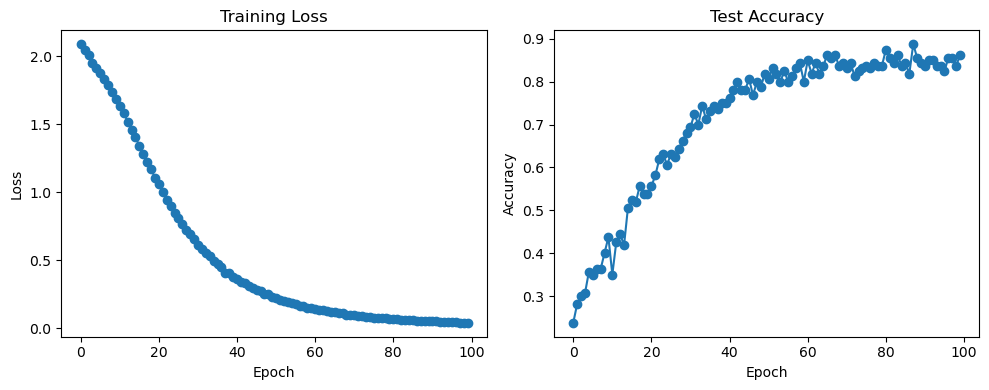

In [43]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, marker="o")
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1, 2, 2)
plt.plot(test_accs, marker="o")
plt.title("Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.tight_layout()
plt.show()

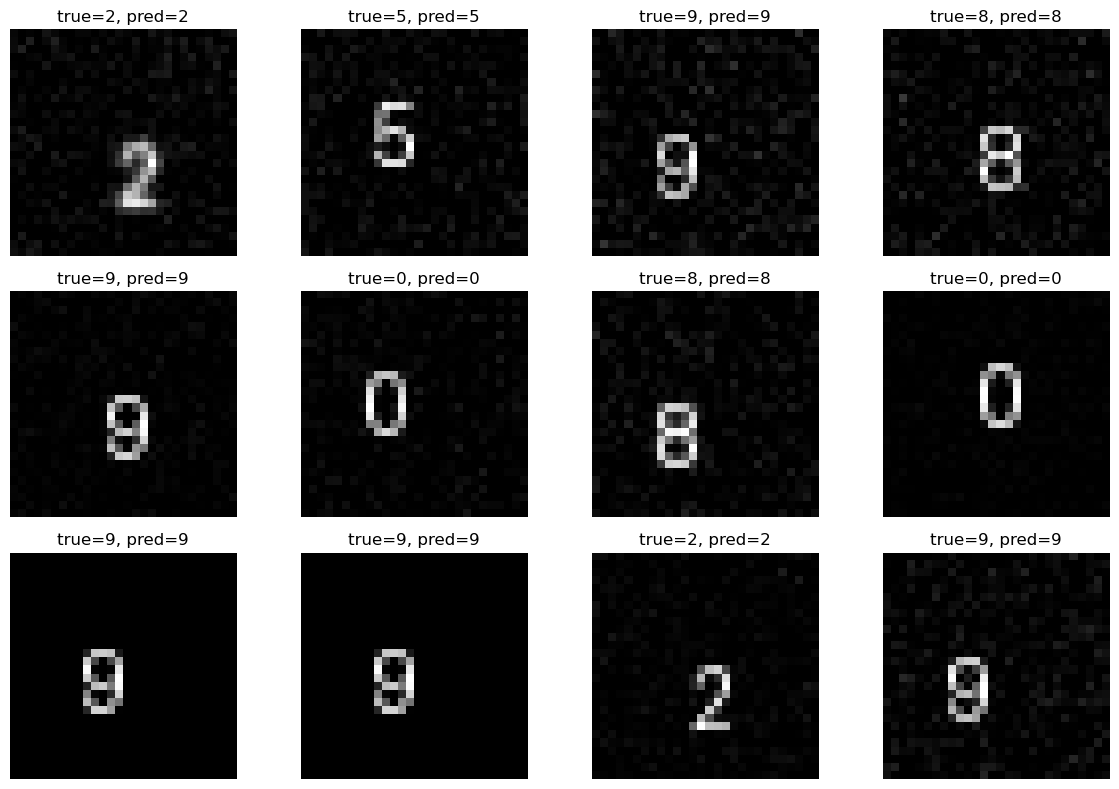

In [45]:
plt.figure(figsize=(12, 8))
for i in range(12):
    idx = np.random.randint(0, len(X_test))
    x = X_test[idx]
    true_label = y_test[idx]
    pred_label, prob = predict_one(x, K, b_conv, W_fc, b_fc)

    plt.subplot(3, 4, i + 1)
    plt.imshow(x, cmap="gray")
    plt.title(f"true={true_label}, pred={pred_label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

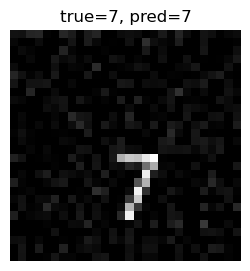

probabilities = [0.    0.004 0.    0.    0.022 0.023 0.    0.951 0.    0.   ]


In [51]:
digit = 7
new_img = make_digit_image(digit, blur=True, noise_level=0.06)

pred, prob = predict_one(new_img, K, b_conv, W_fc, b_fc)

plt.figure(figsize=(3, 3))
plt.imshow(new_img, cmap="gray")
plt.title(f"true={digit}, pred={pred}")
plt.axis("off")
plt.show()

print("probabilities =", np.round(prob, 3))

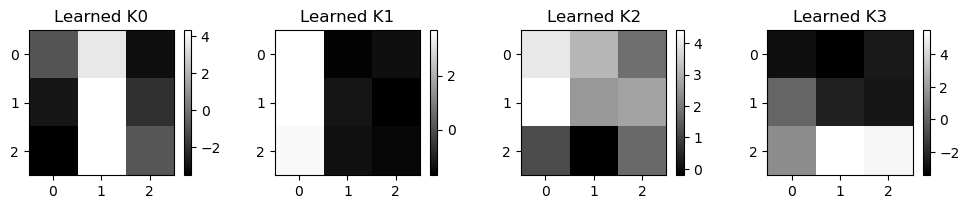

In [52]:
plt.figure(figsize=(10, 2))
for f in range(K.shape[0]):
    plt.subplot(1, K.shape[0], f + 1)
    plt.imshow(K[f], cmap="gray")
    plt.title(f"Learned K{f}")
    plt.colorbar()
plt.tight_layout()
plt.show()

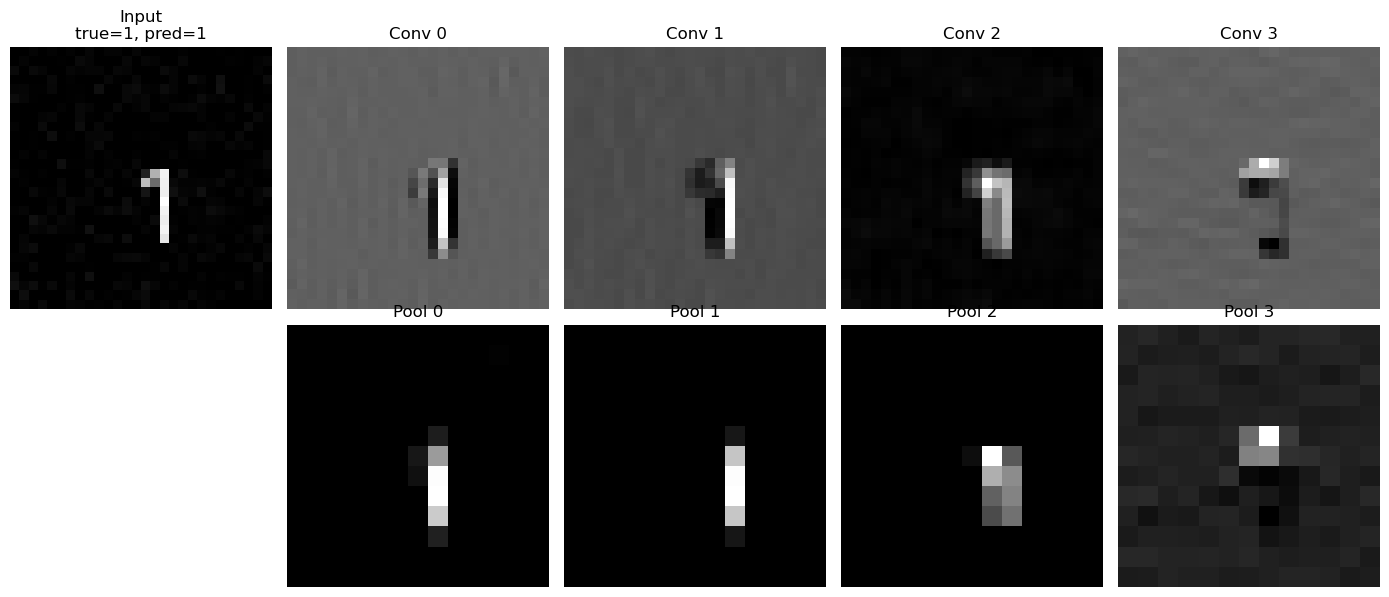

In [53]:
idx = np.random.randint(0, len(X_test))
sample = X_test[idx]
true_label = y_test[idx]

prob, cache = single_channel_cnn_forward(sample, K, b_conv, W_fc, b_fc)
pred_label = np.argmax(prob)

plt.figure(figsize=(14, 6))

plt.subplot(2, 5, 1)
plt.imshow(sample, cmap="gray")
plt.title(f"Input\ntrue={true_label}, pred={pred_label}")
plt.axis("off")

for f in range(4):
    plt.subplot(2, 5, f + 2)
    plt.imshow(cache["z1"][f], cmap="gray")
    plt.title(f"Conv {f}")
    plt.axis("off")

for f in range(4):
    plt.subplot(2, 5, f + 7)
    plt.imshow(cache["p1"][f], cmap="gray")
    plt.title(f"Pool {f}")
    plt.axis("off")

plt.tight_layout()
plt.show()

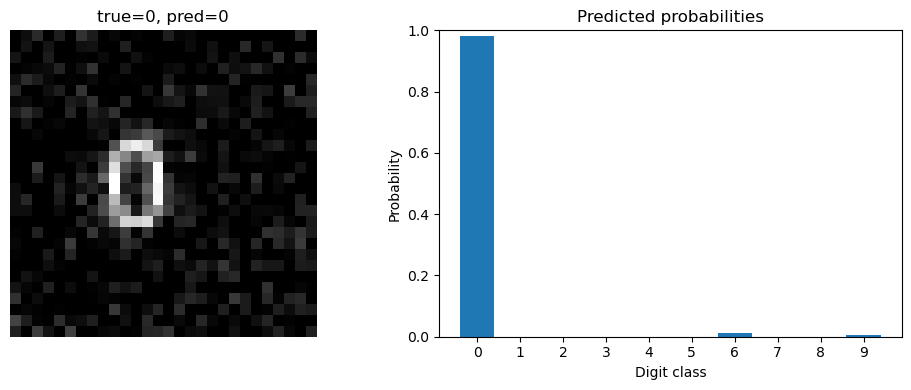

In [54]:
idx = np.random.randint(0, len(X_test))
sample = X_test[idx]
true_label = y_test[idx]

pred, prob = predict_one(sample, K, b_conv, W_fc, b_fc)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(sample, cmap="gray")
plt.title(f"true={true_label}, pred={pred}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.bar(np.arange(10), prob)
plt.xticks(np.arange(10))
plt.ylim(0, 1)
plt.title("Predicted probabilities")
plt.xlabel("Digit class")
plt.ylabel("Probability")

plt.tight_layout()
plt.show()